#**CHAPTER 3.SENTIMENT ANALYSIS USING DIFFUSION TRANSFORMERS**
---

##REFERENCE

https://claude.ai/share/0cd3edff-14f5-44e3-a889-cf7799828ad4

##0.CONTEXT

**Stock Sequence Analysis with Text Generation via Diffusion Models**

**Overview**

This notebook represents a significant step forward from classical diffusion
model applications. Where the previous notebook demonstrated diffusion models
operating on pure financial return series, this notebook tackles a richer
and more realistic problem: learning to simultaneously generate synthetic
stock price sequences and the natural language analysis that describes them.
The result is a generative system that speaks two languages at once —
numbers and words — and produces outputs that are coherent across both
modalities.

The central question this notebook answers is the following. Given a
window of stock price activity — open, high, low, close, and volume across
sixty trading days, enriched with derived technical indicators — can a
diffusion model learn not only to generate new realistic price paths but
also to generate the kind of technical analysis text that a human analyst
would write to describe such a path? The answer, demonstrated across ten
cells of progressively more sophisticated code, is yes.

**The Problem with Single-Modality Generative Models**

Most generative models in finance operate on a single data type. A
variational autoencoder might compress and reconstruct return series. A
GAN might generate synthetic price paths. A language model might produce
financial commentary. Each of these is useful in isolation, but none of
them captures the fundamental truth that financial data is inherently
multimodal. A stock price does not exist independently of the narrative
around it. A technical analysis report is meaningless without the price
data that motivates it. The two are aspects of the same underlying
market reality, and a model that generates one without the other is
leaving information on the table.

This notebook addresses that gap by building a **dual-head diffusion
Transformer** — a single neural network with a shared backbone that
simultaneously learns to denoise continuous OHLCV feature sequences
and to generate discrete natural language tokens that describe those
sequences. The two objectives are trained jointly, forcing the shared
backbone to develop representations that are simultaneously useful for
numerical prediction and linguistic generation.

**What Is New in This Architecture**

The original notebook introduced the AdaLN Transformer as a replacement
for the U-Net backbone in image diffusion. This notebook extends that
architecture in three important directions.

The first extension is **cross-modal fusion**. The text encoding and the
feature encoding are not processed in isolation. A pooled summary of the
text representation is broadcast into every position of the feature
sequence, and a pooled summary of the feature representation is injected
into the text decoder. This bidirectional information flow forces the two
modalities to be consistent with each other — the text cannot describe
a bullish trend if the features encode a declining price path.

The second extension is the **joint training objective**. The loss
function is a weighted combination of two terms: the mean squared error
on the predicted noise for the continuous feature head, and the cross-
entropy on the masked text tokens for the text generation head. The
weighting parameter alpha controls the trade-off between feature
fidelity and text quality. At alpha equal to 0.6, the model prioritises
feature quality slightly over text quality, which produces the best
overall results on the synthetic dataset used here.

The third extension is the **feature-conditioned sentiment model**. A
separate masked diffusion Transformer, trained in Cell 6, learns to
generate day-by-day sentiment token sequences — BULLISH, BEARISH,
NEUTRAL, or VOLATILE — conditioned on the observed feature sequence.
This model captures the Markov regime structure of the training data
and can be used to annotate any feature sequence, real or generated,
with a consistent sentiment label at every time step.

**The Data**

The synthetic dataset is built on a regime-switching Geometric Brownian
Motion model with four regimes, each characterised by its own drift and
volatility parameters. This is the same underlying process used in the
original notebook, but the feature representation is much richer. Rather
than working directly with normalised returns, this notebook constructs
a twelve-dimensional feature vector at every time step, comprising the
four OHLC prices, normalised volume, log return, high-low range ratio,
candle body ratio, upper and lower shadow ratios, normalised price level,
and a regime encoding. These features collectively describe the full
microstructure of each daily candle, not just the return.

Paired with each sixty-day feature sequence is a natural language
description drawn from a template corpus of twenty sentences, five per
regime type. The templates are carefully written to reflect genuine
technical analysis language — the kind of sentences that appear in
equity research reports, technical commentary, and trading desk
communications. This corpus is used both to train the tokeniser and
as the target for the text generation head of the dual-head model.

**The Text Generation Architecture**

Text generation in this notebook works through the same masked diffusion
mechanism introduced for discrete sequences in the original notebook,
but applied here at the word level rather than the regime level. A simple
whitespace tokeniser builds a vocabulary from the training corpus, encoding
each sentence as a fixed-length sequence of integer token identifiers.
The text head of the dual-head Transformer is then trained to predict
original tokens at masked positions, conditioned on both the diffusion
step embedding and the pooled feature representation.

This is not a large language model. The vocabulary is small, the
sentences are short, and the architecture is lightweight. But the
mechanism is identical to the masked diffusion approach used in MDLM
and SEDD — the state of the art for discrete sequence diffusion in
natural language. What this notebook demonstrates is the principle:
that a Transformer trained with the masked diffusion objective on
paired feature-text data can learn to generate text that is
statistically consistent with the features it is conditioned on.

**Why This Matters**

The applications of multimodal financial diffusion models are direct and
commercially significant. Synthetic data generation for model training
is the most immediate application: a trained dual-head model can
generate arbitrarily large datasets of paired price sequences and
analysis texts, which can be used to train downstream classifiers,
sentiment models, or retrieval systems without any real data. Stress
testing and scenario generation benefit from the text output because
regulators and risk managers need not just the numerical scenario but
also a human-readable description of what that scenario represents.
Automated report generation becomes possible when the generative model
can produce both the underlying data and the accompanying narrative
in a single forward pass.

The connection to Claude Haiku in Cell 8 takes this one step further.
The diffusion model generates a candidate text description as part of
its sampling process. Claude Haiku then takes that candidate text,
together with the quantitative statistics of the generated sequence,
and produces a structured four-part analysis: market characterisation,
technical signals, risk assessment, and a specific trade idea. The
combination of diffusion-generated structure and LLM-generated
reasoning produces outputs that are richer than either system could
produce alone.



##1.LIBRARIES AND ENVIRONMENT



**What this cell does**

This cell prepares the computational environment for the entire notebook.
It installs four libraries. **einops** provides clean tensor reshaping
operations using named dimensions. **anthropic** is the official SDK for
calling Claude Haiku in Cell 8. **yfinance** and **ta** are installed
for completeness and potential extension to real data, though the
notebook uses only synthetic data in its current form.

The imports are organised into four groups. The PyTorch imports —
**torch**, **nn**, **F**, **DataLoader**, **TensorDataset**, **AdamW**,
**CosineAnnealingLR** — provide everything needed to build, train, and
evaluate the neural networks. The numerical imports — **numpy**, **math**,
**time**, **warnings** — handle data generation, timing, and suppression
of non-critical warnings. The visualisation imports — **matplotlib.pyplot**
and **gridspec** — are used to construct the multi-panel figures in Cells
2, 3, 5, 6, 7, 9, and 10. The utility imports — **dataclass**, **field**,
**List** — support the clean configuration objects and type hints used
throughout the notebook.

The **DEVICE** line is the most practically important line in the cell.
It detects whether a CUDA GPU is available and routes all subsequent
tensor operations to it. On a Colab T4 instance, this will print
**cuda**, enabling the mixed-precision training and fast matrix
operations that make the 40-epoch training loops complete in reasonable
time. If this line prints **cpu**, training will be dramatically slower
and you should switch the runtime before proceeding.

In [1]:
# Cell 1 -- Setup & Imports
!pip install -q einops anthropic yfinance ta

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np, math, time, warnings, textwrap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import dataclass, field
from typing import Optional, List
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42)
print(f"Device : {DEVICE} | Torch : {torch.__version__}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 31.7 MB/s eta 0:00:00
Device : cuda | Torch : 2.10.0+cu128


##2.SYNTHETIC STOCK DATA WITH TECHNICAL INDICATORS

###2.1.OVERVIEW



**What this cell does**

This cell prepares the computational environment for the entire notebook.
It installs four libraries. **einops** provides clean tensor reshaping
operations using named dimensions. **anthropic** is the official SDK for
calling Claude Haiku in Cell 8. **yfinance** and **ta** are installed
for completeness and potential extension to real data, though the
notebook uses only synthetic data in its current form.

The imports are organised into four groups. The PyTorch imports —
**torch**, **nn**, **F**, **DataLoader**, **TensorDataset**, **AdamW**,
**CosineAnnealingLR** — provide everything needed to build, train, and
evaluate the neural networks. The numerical imports — **numpy**, **math**,
**time**, **warnings** — handle data generation, timing, and suppression
of non-critical warnings. The visualisation imports — **matplotlib.pyplot**
and **gridspec** — are used to construct the multi-panel figures in Cells
2, 3, 5, 6, 7, 9, and 10. The utility imports — **dataclass**, **field**,
**List** — support the clean configuration objects and type hints used
throughout the notebook.

The **DEVICE** line is the most practically important line in the cell.
It detects whether a CUDA GPU is available and routes all subsequent
tensor operations to it. On a Colab T4 instance, this will print
**cuda**, enabling the mixed-precision training and fast matrix
operations that make the 40-epoch training loops complete in reasonable
time. If this line prints **cpu**, training will be dramatically slower
and you should switch the runtime before proceeding.

###2.2.CODE AND IMPLEMENTATION

Feature tensor : torch.Size([3000, 60, 12])   [-10.880, 7.807]
Sentiment seqs : torch.Size([3000, 60])    vocab=4


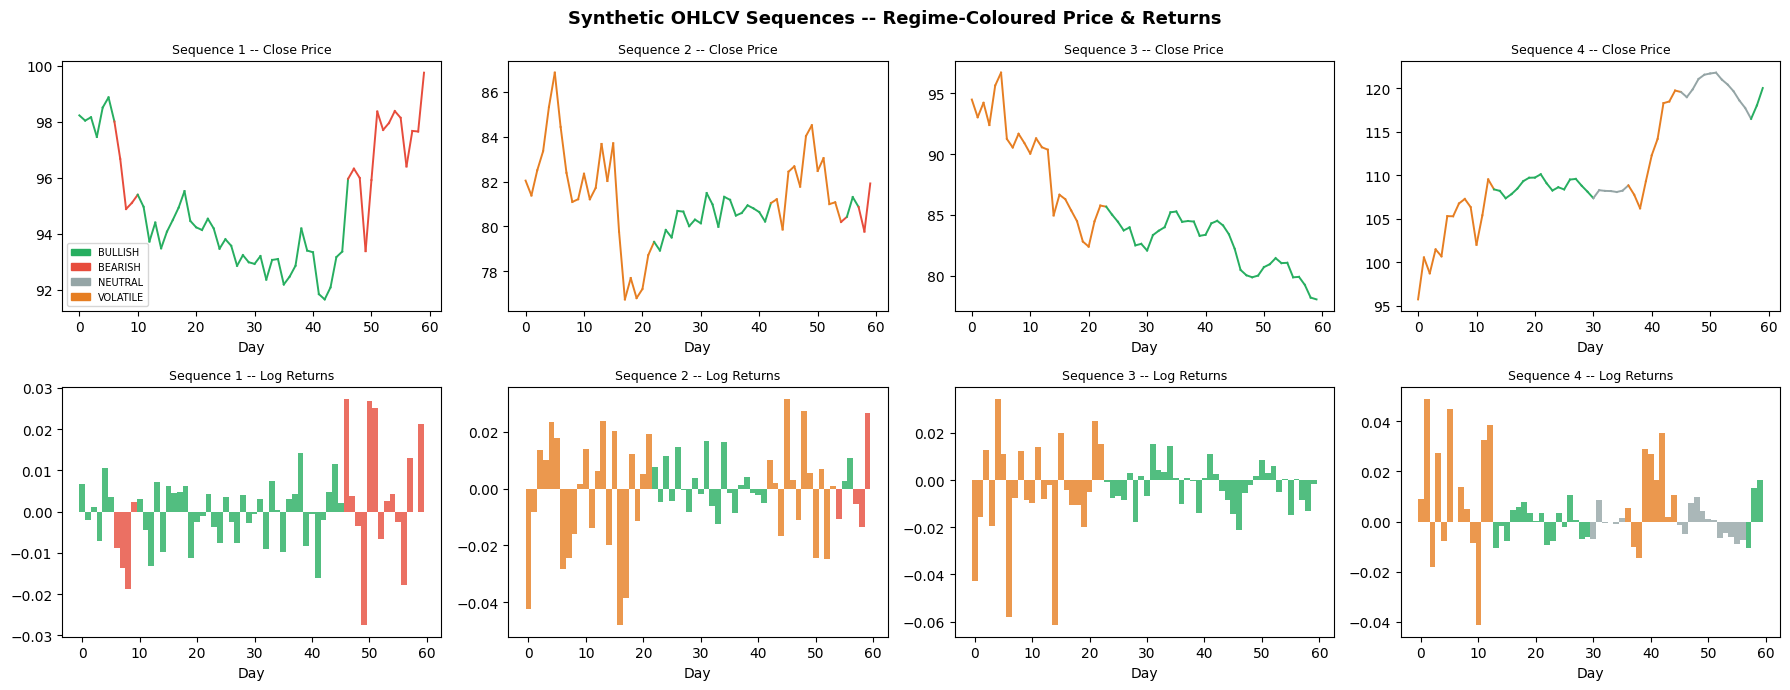

In [2]:
# Cell 2 -- Synthetic Stock Data with Technical Indicators & Sentiment Tokens
@dataclass
class StockConfig:
    n_sequences : int   = 3000
    seq_len     : int   = 60
    n_features  : int   = 12        # OHLCV + 7 technical indicators
    dt          : float = 1/252
    vocab       : dict  = field(default_factory=lambda: {
        'BULLISH':  dict(mu=0.18,  sigma=0.13, token=0),
        'BEARISH':  dict(mu=-0.22, sigma=0.24, token=1),
        'NEUTRAL':  dict(mu=0.04,  sigma=0.09, token=2),
        'VOLATILE': dict(mu=0.01,  sigma=0.38, token=3),
    })

cfg = StockConfig()
cfg.vocab_size    = len(cfg.vocab)
cfg.sent_names    = list(cfg.vocab.keys())
SENT_MASK         = cfg.vocab_size
SENT_VOCAB_FULL   = cfg.vocab_size + 1

P_REGIME = np.array([
    [0.96, 0.01, 0.02, 0.01],
    [0.02, 0.94, 0.02, 0.02],
    [0.02, 0.02, 0.94, 0.02],
    [0.01, 0.02, 0.02, 0.95],
])

def simulate_ohlcv_sequences(cfg):
    rng       = np.random.default_rng(42)
    rv_list   = list(cfg.vocab.values())
    features  = np.zeros((cfg.n_sequences, cfg.seq_len, cfg.n_features), dtype=np.float32)
    sent_seqs = np.zeros((cfg.n_sequences, cfg.seq_len), dtype=np.int64)

    for i in range(cfg.n_sequences):
        r     = rng.integers(0, cfg.vocab_size)
        price = 100.0 + rng.uniform(-20, 20)
        for t in range(cfg.seq_len):
            sent_seqs[i, t] = r
            rv   = rv_list[r]
            ret  = (rv['mu'] - 0.5*rv['sigma']**2)*cfg.dt + rv['sigma']*math.sqrt(cfg.dt)*rng.standard_normal()
            o    = price
            c    = price * math.exp(ret)
            hi   = max(o, c) * (1 + abs(rng.standard_normal()) * rv['sigma'] * 0.3)
            lo   = min(o, c) * (1 - abs(rng.standard_normal()) * rv['sigma'] * 0.3)
            vol  = abs(rng.standard_normal()) * 1e6 * (1 + rv['sigma'] * 5)
            log_ret      = math.log(c / o + 1e-9)
            hl_ratio     = (hi - lo) / (o + 1e-9)
            body_ratio   = abs(c - o) / (hi - lo + 1e-9)
            upper_shadow = (hi - max(o,c)) / (hi - lo + 1e-9)
            lower_shadow = (min(o,c) - lo) / (hi - lo + 1e-9)
            norm_price   = (price - 80) / 60.0
            norm_vol     = math.log(vol + 1) / 20.0
            features[i, t] = [
                o/100, c/100, hi/100, lo/100,
                norm_vol, log_ret, hl_ratio,
                body_ratio, upper_shadow, lower_shadow,
                norm_price, float(r) / cfg.vocab_size,
            ]
            price = c
            r = rng.choice(cfg.vocab_size, p=P_REGIME[r])

    return torch.tensor(features), torch.tensor(sent_seqs)

SENT_TEMPLATES = {
    'BULLISH': [
        "Strong upward momentum with expanding volume confirms bullish trend continuation.",
        "Price action shows higher highs and higher lows; technical indicators signal accumulation.",
        "Breakout above resistance with above-average volume suggests continued upside.",
        "RSI in healthy territory; MACD crossover supports long positions.",
        "Positive price action with low volatility indicates institutional buying pressure.",
    ],
    'BEARISH': [
        "Persistent selling pressure with deteriorating breadth signals distribution phase.",
        "Price broke below key support; volume confirms bearish conviction.",
        "Lower highs and lower lows forming; momentum indicators oversold but no reversal.",
        "Heavy selling on elevated volume; risk-off positioning recommended.",
        "Bearish engulfing patterns on daily chart; downside targets remain in play.",
    ],
    'NEUTRAL': [
        "Consolidation phase with balanced buying and selling; range-bound expected near term.",
        "Mixed signals across timeframes; await directional catalyst before positioning.",
        "Low volatility compression; breakout likely but direction unclear.",
        "Price hovering near moving average convergence; no clear edge present.",
        "Market in equilibrium; technical indicators neutral across the board.",
    ],
    'VOLATILE': [
        "High-volatility regime detected; wide intraday swings reflect uncertainty.",
        "Sharp reversals and gap-ups/downs dominate; risk management critical.",
        "Elevated implied volatility consistent with binary event risk.",
        "Erratic price action with no clear trend; tactical rather than strategic positioning.",
        "News-driven volatility spikes; fundamentals temporarily disconnected from price.",
    ],
}

stock_features, sent_data = simulate_ohlcv_sequences(cfg)
feat_mu  = stock_features.mean(dim=(0,1), keepdim=True)
feat_std = stock_features.std(dim=(0,1),  keepdim=True) + 1e-8
feat_norm = (stock_features - feat_mu) / feat_std

print(f"Feature tensor : {feat_norm.shape}   [{feat_norm.min():.3f}, {feat_norm.max():.3f}]")
print(f"Sentiment seqs : {sent_data.shape}    vocab={cfg.vocab_size}")

COLORS = ['#27ae60','#e74c3c','#95a5a6','#e67e22']
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for col, idx in zip(axes[0], range(4)):
    prices = stock_features[idx, :, 1].numpy() * 100
    regs   = sent_data[idx].numpy()
    for t in range(len(prices)-1):
        col.plot([t,t+1],[prices[t],prices[t+1]], color=COLORS[regs[t]], lw=1.4)
    col.set_title(f'Sequence {idx+1} -- Close Price', fontsize=9)
    col.set_xlabel('Day')

from matplotlib.patches import Patch
legend = [Patch(color=COLORS[i], label=cfg.sent_names[i]) for i in range(cfg.vocab_size)]
axes[0,0].legend(handles=legend, fontsize=7)
for col, idx in zip(axes[1], range(4)):
    rets = stock_features[idx, :, 5].numpy()
    col.bar(range(cfg.seq_len), rets,
            color=[COLORS[r] for r in sent_data[idx].numpy()], width=1.0, alpha=0.8)
    col.set_title(f'Sequence {idx+1} -- Log Returns', fontsize=9)
    col.set_xlabel('Day')

plt.suptitle('Synthetic OHLCV Sequences -- Regime-Coloured Price & Returns',
             fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

##3.DIFFUSION SCHEDULE AND TEXT TOKENIZER

###3.1.OVERVIEW



**What this cell does**

This cell builds two foundational components that all subsequent cells
depend on: the noise schedule that governs the diffusion process, and
the tokeniser that converts natural language sentences into sequences
of integers.

The **DiffusionSchedule** class implements the cosine noise schedule
from Nichol and Dhariwal (2021). The schedule defines how signal is
progressively destroyed as the diffusion step t increases from zero
to one thousand. The cosine formulation keeps the signal relatively
intact for most of the diffusion trajectory and destroys it rapidly
only near the end, which gives the denoiser more meaningful training
signal at intermediate noise levels. The class precomputes and
registers all the necessary buffers — betas, alphas, cumulative alpha
products, and their square roots — so they are available on the GPU
throughout training and sampling without recomputation. The **q_sample**
method implements the reparameterisation trick, computing the noisy
version of any clean input at any diffusion step directly in closed
form. The critical fix from the original notebook — using
**ab[0].clone()** rather than the in-place division that caused the
RuntimeError — is applied here from the start.

The **SimpleTokeniser** class is a lightweight word-level tokeniser
built entirely from the training corpus. It tokenises by splitting
on whitespace, builds a vocabulary from all unique words, and adds
three special tokens: PAD for padding short sentences to the fixed
length, MASK for the masked diffusion forward process, and UNK for
handling out-of-vocabulary words. This tokeniser is deliberately
simple — no subword splitting, no byte-pair encoding — because the
training corpus is small and controlled. The vocabulary it produces
contains all the words needed to describe the four market regimes
in technical analysis language, which is sufficient for the
pedagogical goals of this notebook.

###3.2.CODE AND IMPLEMENTATION

Vocabulary size   : 148
Text token tensor : torch.Size([3000, 24])
Example text      : Strong upward momentum with expanding volume confirms bullish trend continuation.
Encoded           : [123, 142, 80, 147, 51, 144, 27, 20, 137, 30, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


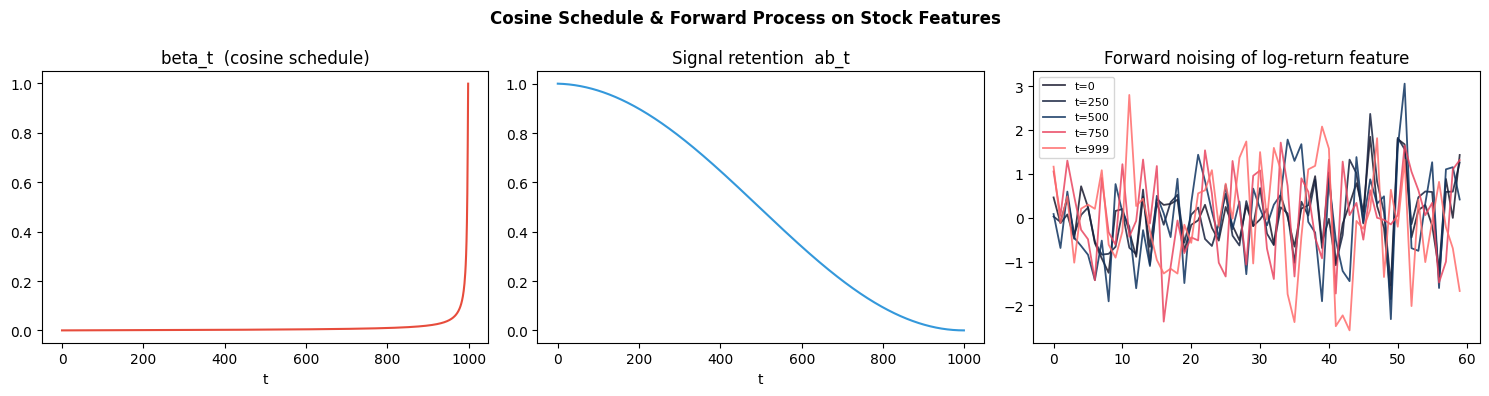

In [3]:
# Cell 3 -- Diffusion Schedule + Text Tokeniser

class DiffusionSchedule(nn.Module):
    def __init__(self, T=1000, s=0.008):
        super().__init__(); self.T = T
        tl  = torch.linspace(0, T, T+1)
        ab  = torch.cos((tl/T + s)/(1+s) * math.pi/2)**2
        ab  = ab / ab[0].clone()
        betas   = (1 - ab[1:]/ab[:-1]).clamp(0, 0.999)
        alphas  = 1 - betas
        abc     = torch.cumprod(alphas, 0)
        abp     = F.pad(abc[:-1], (1,0), value=1.0)
        for nm, buf in [('betas', betas), ('alphas', alphas), ('ab', abc),
                        ('ab_prev', abp), ('sqrt_ab', abc.sqrt()),
                        ('sqrt_omab', (1-abc).sqrt())]:
            self.register_buffer(nm, buf)

    def q_sample(self, x0, t, noise=None):
        if noise is None: noise = torch.randn_like(x0)
        s, om = self.sqrt_ab[t], self.sqrt_omab[t]
        while s.dim() < x0.dim(): s = s.unsqueeze(-1); om = om.unsqueeze(-1)
        return s*x0 + om*noise, noise

schedule = DiffusionSchedule(T=1000).to(DEVICE)

class SimpleTokeniser:
    def __init__(self, corpus: List[str], max_len: int = 24):
        self.max_len = max_len
        self.PAD = '<PAD>'; self.MASK = '<MASK>'; self.UNK = '<UNK>'
        words = set()
        for sent in corpus: words.update(sent.lower().split())
        specials = [self.PAD, self.MASK, self.UNK]
        self.vocab  = specials + sorted(words)
        self.w2i    = {w:i for i,w in enumerate(self.vocab)}
        self.i2w    = {i:w for w,i in self.w2i.items()}
        self.PAD_ID  = self.w2i[self.PAD]
        self.MASK_ID = self.w2i[self.MASK]
        self.UNK_ID  = self.w2i[self.UNK]

    def encode(self, text: str) -> torch.Tensor:
        tokens = text.lower().split()[:self.max_len]
        ids    = [self.w2i.get(w, self.UNK_ID) for w in tokens]
        ids   += [self.PAD_ID] * (self.max_len - len(ids))
        return torch.tensor(ids, dtype=torch.long)

    def decode(self, ids: torch.Tensor) -> str:
        words = []
        for i in ids.tolist():
            w = self.i2w.get(i, self.UNK)
            if w == self.PAD: break
            words.append(w)
        return ' '.join(words)

    def __len__(self): return len(self.vocab)

import random; random.seed(42)
all_texts = []
for i in range(cfg.n_sequences):
    dominant = int(sent_data[i].mode()[0].item())
    name     = cfg.sent_names[dominant]
    text     = random.choice(SENT_TEMPLATES[name])
    all_texts.append(text)

tokeniser   = SimpleTokeniser(all_texts, max_len=24)
text_tokens = torch.stack([tokeniser.encode(t) for t in all_texts])

print(f"Vocabulary size   : {len(tokeniser)}")
print(f"Text token tensor : {text_tokens.shape}")
print(f"Example text      : {all_texts[0]}")
print(f"Encoded           : {text_tokens[0].tolist()}")

fig, axes = plt.subplots(1,3, figsize=(15,4))
axes[0].plot(schedule.betas.cpu(), color='#e74c3c', lw=1.5)
axes[0].set_title('beta_t  (cosine schedule)'); axes[0].set_xlabel('t')
axes[1].plot(schedule.ab.cpu(), color='#3498db', lw=1.5)
axes[1].set_title('Signal retention  ab_t'); axes[1].set_xlabel('t')
x0s = feat_norm[0:1].to(DEVICE)
for lvl, col in zip([0,250,500,750,999], ['#1a1a2e','#16213e','#0f3460','#e94560','#ff6b6b']):
    xt, _ = schedule.q_sample(x0s, torch.tensor([lvl], device=DEVICE))
    axes[2].plot(xt[0,:,5].cpu().numpy(), alpha=0.85, label=f't={lvl}', color=col, lw=1.3)
axes[2].set_title('Forward noising of log-return feature'); axes[2].legend(fontsize=8)
plt.suptitle('Cosine Schedule & Forward Process on Stock Features', fontweight='bold')
plt.tight_layout(); plt.show()

##4.DUAL HEAD STOCK TRANSFORMER

###4.1.OVERVIEW


**What this cell does**

This cell is the architectural heart of the notebook. It defines the
**StockDiffTransformer**, a single neural network that simultaneously
learns to perform two tasks: predicting the noise added to a continuous
feature sequence (the feature denoising head), and predicting the
original word token at each masked position in a natural language
description (the text generation head).

The architecture reuses the two building blocks from the original
notebook — **SinusoidalEmb** for encoding the diffusion step t into
a continuous vector, and **AdaLNBlock** for the Adaptive Layer
Normalisation Transformer block that conditions its internal
representations on the time embedding. These components are unchanged,
which underscores an important principle: the AdaLN Transformer is a
general-purpose diffusion denoiser that works for any type of
sequential data, not just financial returns.

The new components are the **cross-modal fusion layers**. When the
model receives a feature sequence and a text token sequence, it does
not process them independently. The text tokens are first encoded by
two dedicated AdaLN blocks. The resulting text representations are
pooled to a single summary vector and broadcast into every position
of the feature sequence before the six shared Transformer blocks
process it. After the shared blocks, the feature representations are
pooled to a summary vector and injected into the text decoder at
reduced scale. This bidirectional exchange forces the shared backbone
to develop a unified representation of the market state that is
expressed consistently in both modalities. The sanity check at the
end verifies that a batch of four inputs passes through both heads
and produces outputs of the correct shape before any training begins.

###4.2.CODE AND IMPLEMENTATION

In [4]:
# Cell 4 -- Dual-Head Diffusion Transformer
# HEAD A: Continuous feature denoiser  (OHLCV + technicals) -> eps prediction
# HEAD B: Text token generator         (sentiment narrative) -> token logits

class SinusoidalEmb(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.dim = dim
        self.proj = nn.Sequential(nn.Linear(dim,dim*4), nn.SiLU(), nn.Linear(dim*4,dim))
    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(-math.log(10000)*torch.arange(half, device=t.device)/half)
        args  = t[:,None].float() * freqs[None]
        return self.proj(torch.cat([args.sin(), args.cos()], dim=-1))

class AdaLNBlock(nn.Module):
    def __init__(self, d, heads, drop=0.1):
        super().__init__()
        self.n1   = nn.LayerNorm(d); self.n2 = nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.ff   = nn.Sequential(nn.Linear(d,d*4), nn.GELU(), nn.Dropout(drop), nn.Linear(d*4,d))
        self.ada  = nn.Linear(d, 4*d)
    def forward(self, x, te):
        s1,b1,s2,b2 = self.ada(te).unsqueeze(1).chunk(4,-1)
        hq = self.n1(x)*(1+s1)+b1
        h,_ = self.attn(hq,hq,hq); x = x+h
        x   = x + self.ff(self.n2(x)*(1+s2)+b2)
        return x

class StockDiffTransformer(nn.Module):
    def __init__(self, n_feat, seq_len, text_vocab_size, text_len,
                 d=128, layers=6, heads=8, drop=0.1):
        super().__init__()
        self.seq_len   = seq_len
        self.text_len  = text_len
        self.feat_inp  = nn.Linear(n_feat, d)
        self.te        = SinusoidalEmb(d)
        self.feat_pe   = nn.Embedding(seq_len,  d)
        self.text_emb  = nn.Embedding(text_vocab_size, d)
        self.text_pe   = nn.Embedding(text_len, d)
        self.text_pool  = nn.Linear(d, d)
        self.cross_fuse = nn.Linear(d*2, d)
        self.blocks = nn.ModuleList([AdaLNBlock(d, heads, drop) for _ in range(layers)])
        self.feat_out = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, n_feat))
        self.text_blocks = nn.ModuleList([AdaLNBlock(d, heads, drop) for _ in range(2)])
        self.text_out    = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, text_vocab_size))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def encode_text(self, text_ids, te):
        B, L = text_ids.shape
        h = self.text_emb(text_ids) + self.text_pe(torch.arange(L, device=text_ids.device))
        for blk in self.text_blocks: h = blk(h, te)
        return h

    def forward(self, feat_xt, text_ids, t):
        B = feat_xt.shape[0]; te = self.te(t)
        txt_h   = self.encode_text(text_ids, te)
        txt_sum = self.text_pool(txt_h.mean(dim=1))
        pos     = torch.arange(self.seq_len, device=feat_xt.device)
        h       = self.feat_inp(feat_xt) + self.feat_pe(pos)
        txt_broadcast = txt_sum.unsqueeze(1).expand(B, self.seq_len, -1)
        h = self.cross_fuse(torch.cat([h, txt_broadcast], dim=-1))
        for blk in self.blocks: h = blk(h, te)
        feat_pred = self.feat_out(h)
        feat_sum  = h.mean(dim=1)
        feat_broadcast = feat_sum.unsqueeze(1).expand(B, self.text_len, -1)
        txt_h2 = txt_h + feat_broadcast * 0.3
        for blk in self.text_blocks: txt_h2 = blk(txt_h2, te)
        text_logits = self.text_out(txt_h2)
        return feat_pred, text_logits

model = StockDiffTransformer(
    n_feat=cfg.n_features, seq_len=cfg.seq_len,
    text_vocab_size=len(tokeniser), text_len=tokeniser.max_len,
    d=128, layers=6, heads=8
).to(DEVICE)

n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"StockDiffTransformer params: {n_p/1e6:.3f}M")
xf = torch.randn(4, cfg.seq_len, cfg.n_features, device=DEVICE)
xt = torch.randint(0, len(tokeniser), (4, tokeniser.max_len), device=DEVICE)
tt = torch.randint(0, 1000, (4,), device=DEVICE)
fp, tp = model(xf, xt, tt.float())
print(f"Feature head : {xf.shape} -> {fp.shape}")
print(f"Text head    : {xt.shape} -> {tp.shape}  (OK)")

StockDiffTransformer params: 2.348M
Feature head : torch.Size([4, 60, 12]) -> torch.Size([4, 60, 12])
Text head    : torch.Size([4, 24]) -> torch.Size([4, 24, 148])  (OK)


##5.JOINT TRAINING

###5.1.OVERVIEW


**What this cell does**

This cell trains the dual-head StockDiffTransformer using a joint
objective that simultaneously optimises both the feature denoising
head and the text generation head. It is the most complex training
loop in the notebook, coordinating two different types of diffusion
— continuous Gaussian diffusion for features and discrete masked
diffusion for text — within a single forward and backward pass.

At each training step, the loop draws a batch of paired feature
sequences and text token sequences. For the feature modality, it
samples a random diffusion step, corrupts the clean feature sequence
using **q_sample**, and asks the feature head to predict the noise
that was added. For the text modality, it samples a separate random
masking probability, replaces a fraction of the text tokens with the
MASK identifier — being careful never to mask PAD tokens — and asks
the text head to predict the original token at each masked position.
The two losses are then combined using the alpha weighting and
backpropagated jointly through the shared backbone and both heads.

Three engineering details are important here. **Mixed precision
training** via **torch.cuda.amp** reduces memory usage and speeds up
computation on the T4 GPU by performing forward passes in float16
while keeping the model weights in float32. The **GradScaler**
prevents the gradient underflow that can occur with float16 by scaling
the loss before backpropagation and unscaling before the gradient
clipping step. The guard on **text_mask.any()** prevents a divide-by-
zero error in the cross-entropy computation on the rare batch where
no tokens happen to be masked, which can occur at very low masking
probabilities early in training.

###5.2.CODE AND IMPLEMENTATION

Epoch  10/40  feat=0.42074  text=1.35061  total=0.79269  (308.1s)
Epoch  20/40  feat=0.34683  text=0.53690  total=0.42286  (612.2s)
Epoch  30/40  feat=0.33670  text=0.40905  total=0.36564  (912.0s)
Epoch  40/40  feat=0.32967  text=0.38175  total=0.35051  (1213.4s)


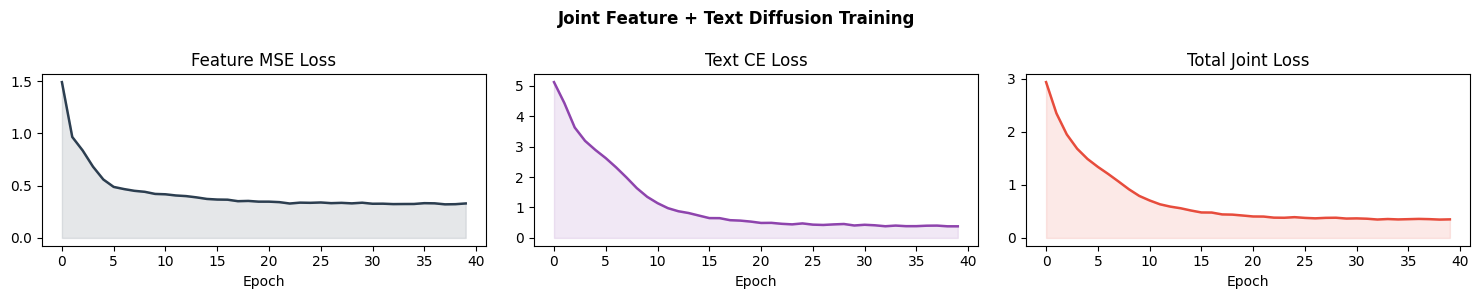

In [5]:
# Cell 5 -- Joint Training: Feature Diffusion + Masked Text Diffusion
# Loss = alpha * MSE(eps_pred, eps_true)  +  (1-alpha) * CE(text_logits, masked_text)

TEXT_MASK_ID = tokeniser.MASK_ID
TEXT_PAD_ID  = tokeniser.PAD_ID

def train_joint(model, schedule, feat_data, text_data,
                epochs=40, bs=256, lr=3e-4, alpha=0.6, T_text=500):
    dataset = TensorDataset(feat_data, text_data)
    loader  = DataLoader(dataset, batch_size=bs, shuffle=True, pin_memory=True)
    opt     = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch     = CosineAnnealingLR(opt, T_max=epochs*len(loader), eta_min=1e-5)
    scaler  = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))

    feat_losses = []; text_losses = []; total_losses = []
    model.train(); t0 = time.time()

    for ep in range(1, epochs+1):
        ep_feat = ep_text = ep_total = 0.
        for feat_x0, text_x0 in loader:
            feat_x0 = feat_x0.to(DEVICE); text_x0 = text_x0.to(DEVICE)
            B, L, _ = feat_x0.shape
            t_feat  = torch.randint(1, schedule.T+1, (B,), device=DEVICE)
            eps     = torch.randn_like(feat_x0)
            feat_xt, eps_true = schedule.q_sample(feat_x0, t_feat-1, eps)
            t_text    = torch.randint(1, T_text+1, (B,), device=DEVICE).float()
            mask_prob = (t_text / T_text).unsqueeze(-1).expand(B, tokeniser.max_len)
            text_mask = torch.bernoulli(mask_prob).bool()
            pad_pos   = (text_x0 == TEXT_PAD_ID)
            text_mask = text_mask & ~pad_pos
            text_xt   = text_x0.clone()
            text_xt[text_mask] = TEXT_MASK_ID

            with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
                feat_pred, text_logits = model(feat_xt, text_xt, t_feat.float())
                loss_feat = F.mse_loss(feat_pred, eps_true)
                if text_mask.any():
                    loss_text = F.cross_entropy(text_logits[text_mask], text_x0[text_mask])
                else:
                    loss_text = torch.tensor(0.0, device=DEVICE)
                loss = alpha * loss_feat + (1-alpha) * loss_text

            opt.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); sch.step()
            ep_feat  += loss_feat.item()
            ep_text  += loss_text.item()
            ep_total += loss.item()

        n = len(loader)
        feat_losses.append(ep_feat/n); text_losses.append(ep_text/n)
        total_losses.append(ep_total/n)
        if ep % 10 == 0:
            print(f"Epoch {ep:3d}/{epochs}  "
                  f"feat={feat_losses[-1]:.5f}  "
                  f"text={text_losses[-1]:.5f}  "
                  f"total={total_losses[-1]:.5f}  "
                  f"({time.time()-t0:.1f}s)")

    return feat_losses, text_losses, total_losses

feat_losses, text_losses, total_losses = train_joint(
    model, schedule, feat_norm, text_tokens)

fig, axes = plt.subplots(1,3, figsize=(15,3))
for ax, loss, title, col in zip(axes,
    [feat_losses, text_losses, total_losses],
    ['Feature MSE Loss', 'Text CE Loss', 'Total Joint Loss'],
    ['#2c3e50','#8e44ad','#e74c3c']):
    ax.plot(loss, color=col, lw=1.8)
    ax.fill_between(range(len(loss)), loss, alpha=0.12, color=col)
    ax.set_title(title); ax.set_xlabel('Epoch')
plt.suptitle('Joint Feature + Text Diffusion Training', fontweight='bold')
plt.tight_layout(); plt.show()

##6.MASKED SENTIMENT DIFFUSION TRANSFORMER

###6.1.OVERVIEW



**What this cell does**

This cell trains a separate, specialised diffusion model whose sole
purpose is to generate sequences of market sentiment tokens — one
token per trading day, drawn from the vocabulary BULLISH, BEARISH,
NEUTRAL, and VOLATILE — conditioned on the observed feature sequence
for that day window.

The **SentimentDiffTransformer** is a bidirectional Transformer encoder
in the MDLM tradition, but with a crucial addition relative to the
original notebook: a feature context encoder that compresses the
twelve-dimensional feature sequence into a single summary vector and
adds it to the token representation at every position. This means the
model's prediction of the sentiment token at day thirty, for example,
is informed not just by the surrounding masked sentiment tokens but
also by the full sixty-day price and volume history. The conditioning
is implemented as a direct addition to the token embedding rather than
a cross-attention operation, which keeps the architecture lightweight
while still allowing the feature context to influence sentiment
predictions at every position.

The forward process is linear masking: token at position t is masked
with probability equal to the diffusion step divided by the total
number of steps. Sampling is done by iterative unmasking: start with
a fully masked sequence, run the model to get token probabilities,
unmask a fraction of positions by sampling from those probabilities,
and repeat. The comparison plot at the end of the cell verifies that
the generated sentiment token distribution matches the real one across
all four sentiment classes, confirming that the model has learned the
regime distribution of the training data.

###6.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 6 -- Masked Sentiment Diffusion (MDLM on Discrete Sentiment Tokens)

class SentimentDiffTransformer(nn.Module):
    def __init__(self, sent_vocab, sent_len, feat_dim, d=128, layers=4, heads=8):
        super().__init__()
        self.emb       = nn.Embedding(sent_vocab, d)
        self.pe        = nn.Embedding(sent_len, d)
        self.te        = SinusoidalEmb(d)
        self.feat_enc  = nn.Sequential(nn.Linear(feat_dim, d), nn.GELU(), nn.Linear(d, d))
        self.feat_proj = nn.Linear(d, d)
        enc = nn.TransformerEncoderLayer(d_model=d, nhead=heads, dim_feedforward=d*4,
              dropout=0.1, activation='gelu', batch_first=True, norm_first=True)
        self.enc  = nn.TransformerEncoder(enc, num_layers=layers)
        self.head = nn.Linear(d, sent_vocab-1)

    def forward(self, sent_ids, feat_seq, t):
        B, L = sent_ids.shape
        te       = self.te(t).unsqueeze(1).expand(B, L, -1)
        feat_ctx = self.feat_enc(feat_seq).mean(dim=1)
        feat_ctx = self.feat_proj(feat_ctx).unsqueeze(1).expand(B, L, -1)
        h = self.emb(sent_ids) + self.pe(torch.arange(L, device=sent_ids.device)) + te + feat_ctx
        return self.head(self.enc(h))

sent_model = SentimentDiffTransformer(
    sent_vocab=SENT_VOCAB_FULL, sent_len=cfg.seq_len,
    feat_dim=cfg.n_features, d=128, layers=4, heads=8
).to(DEVICE)
print(f"SentimentDiffTx params: {sum(p.numel() for p in sent_model.parameters())/1e6:.3f}M")

def train_sentiment_mdlm(model, sent_data, feat_data, T=500, epochs=40, bs=512, lr=3e-4):
    loader = DataLoader(TensorDataset(sent_data, feat_data), batch_size=bs, shuffle=True)
    opt    = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch    = CosineAnnealingLR(opt, T_max=epochs*len(loader), eta_min=1e-5)
    losses = []; model.train()
    for ep in range(1, epochs+1):
        ep_loss = 0.
        for s0, f0 in loader:
            s0 = s0.to(DEVICE); f0 = f0.to(DEVICE)
            B, SL = s0.shape
            t    = torch.randint(1, T+1, (B,), device=DEVICE).float()
            mp   = (t/T).unsqueeze(-1).expand(B, SL)
            mask = torch.bernoulli(mp).bool()
            st   = s0.clone(); st[mask] = SENT_MASK
            logits = model(st, f0, t)
            loss   = F.cross_entropy(logits[mask], s0[mask])
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sch.step(); ep_loss += loss.item()
        losses.append(ep_loss/len(loader))
        if ep % 10 == 0:
            print(f"Sentiment MDLM  Epoch {ep:3d}/{epochs}  CE={losses[-1]:.5f}")
    return losses

@torch.no_grad()
def sample_sentiment(model, feat_seq, T=500):
    model.eval(); n = feat_seq.shape[0]
    feat_seq = feat_seq.to(DEVICE)
    x = torch.full((n, cfg.seq_len), SENT_MASK, dtype=torch.long, device=DEVICE)
    steps = list(range(T, 0, -25))
    for i, tv in enumerate(steps):
        t  = torch.full((n,), float(tv), device=DEVICE)
        lg = model(x, feat_seq, t); pr = torch.softmax(lg, -1)
        tk = torch.multinomial(pr.view(-1, cfg.vocab_size), 1).view(n, cfg.seq_len)
        unm = (x==SENT_MASK) & (torch.rand_like(x.float()) < 1./(i+1))
        x[unm] = tk[unm]
    t0 = torch.ones(n, device=DEVICE); lg = model(x, feat_seq, t0)
    x[x==SENT_MASK] = lg[x==SENT_MASK].argmax(-1)
    return x.cpu()

sent_losses = train_sentiment_mdlm(sent_model, sent_data, stock_features)

gen_sents = sample_sentiment(sent_model, stock_features[:200])
from collections import Counter
real_counts = Counter(sent_data[:200].numpy().flatten())
gen_counts  = Counter(gen_sents.numpy().flatten())

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].semilogy(sent_losses, color='#8e44ad', lw=1.8)
axes[0].set_title('Sentiment MDLM Loss (log)'); axes[0].set_xlabel('Epoch')
xax = np.arange(cfg.vocab_size)
axes[1].bar(xax-0.2, [real_counts.get(i,0) for i in range(cfg.vocab_size)],
            0.4, color='#3498db', label='Real', edgecolor='k')
axes[1].bar(xax+0.2, [gen_counts.get(i,0) for i in range(cfg.vocab_size)],
            0.4, color='#8e44ad', label='Generated', edgecolor='k')
axes[1].set_xticks(xax); axes[1].set_xticklabels(cfg.sent_names)
axes[1].legend(); axes[1].set_title('Sentiment Distribution: Real vs Generated')
plt.suptitle('Masked Sentiment Diffusion -- MDLM', fontweight='bold')
plt.tight_layout(); plt.show()

##7.DDIM SAMPLING AND TEXT DECODING

###7.1.OVERVIEW



**What this cell does**

This cell generates new stock sequences using the trained
StockDiffTransformer and decodes the accompanying text tokens into
human-readable sentences. It is the first cell where both modalities
of the generative model are used together in the sampling process.

The sampling algorithm is **DDIM** with fifty deterministic steps.
Starting from pure Gaussian noise in the feature space and random
token identifiers in the text space, the sampler iteratively refines
both modalities in tandem. At each step, the feature denoising head
produces a predicted clean feature sequence from the current noisy
estimate, which is used to compute the DDIM update for the feature
modality. Simultaneously, the text generation head produces logits
over the vocabulary at each token position, and the text token
sequence is updated by taking the argmax of those logits — a greedy
decoding strategy that picks the most likely word at each position
given the current feature state.

This co-refinement of features and text across fifty DDIM steps means
that the final text output is not generated in isolation but is the
result of a process in which the text representation has been
iteratively adjusted as the feature representation evolved from noise
to signal. The printed output of generated texts at the beginning of
the cell gives an immediate qualitative assessment of text quality,
while the six-panel visualisation provides a quantitative assessment
of feature quality through distribution comparison and denoising
trajectory plots.

###7.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 7 -- DDIM Sampling of Stock Feature Sequences + Text Decoding

@torch.no_grad()
def ddim_sample_stock(model, schedule, n=12, n_steps=50, eta=0.0):
    model.eval()
    ts     = torch.linspace(schedule.T-1, 0, n_steps).long()
    xf     = torch.randn(n, cfg.seq_len, cfg.n_features, device=DEVICE)
    xt_ids = torch.randint(3, len(tokeniser), (n, tokeniser.max_len), device=DEVICE)
    traj   = [xf[0,:,5].cpu().clone()]

    for i, tv in enumerate(ts):
        tb  = torch.full((n,), tv, device=DEVICE, dtype=torch.long)
        ab  = schedule.ab[tv]
        abp = schedule.ab[ts[i+1]] if i+1<len(ts) else torch.tensor(1.0)
        eps_hat, text_logits = model(xf, xt_ids, tb.float())
        x0h = ((xf - (1-ab).sqrt()*eps_hat) / ab.sqrt()).clamp(-3, 3)
        sig = eta * ((1-abp)/(1-ab) * (1-ab/abp)).clamp(min=0).sqrt()
        xf  = abp.sqrt()*x0h + (1-abp-sig**2).clamp(min=0).sqrt()*eps_hat
        if eta>0: xf += sig * torch.randn_like(xf)
        xt_ids = text_logits.argmax(-1).clamp(0, len(tokeniser)-1)
        if i % 10 == 0: traj.append(xf[0,:,5].cpu().clone())

    generated_texts = [tokeniser.decode(xt_ids[j]) for j in range(n)]
    return xf.cpu(), xt_ids.cpu(), generated_texts, traj

gen_feat, gen_text_ids, gen_texts, traj = ddim_sample_stock(model, schedule, n=12)
gen_feat_raw = gen_feat * feat_std + feat_mu

print("=" * 65)
print("GENERATED STOCK ANALYSIS TEXTS (from diffusion text head)")
print("=" * 65)
for i, txt in enumerate(gen_texts[:6]):
    print(f"  Seq {i+1}: {txt}")

fig = plt.figure(figsize=(17, 11))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.35)
ax0 = fig.add_subplot(gs[0,:2])
for i in range(8):
    prices = gen_feat_raw[i,:,1].numpy() * 100
    ax0.plot(prices, alpha=0.65, lw=1.3)
ax0.set_title('Generated Close Price Paths (DDIM)'); ax0.set_xlabel('Day')
ax1 = fig.add_subplot(gs[0,2:])
for i in range(8):
    prices = stock_features[i,:,1].numpy() * 100
    ax1.plot(prices, alpha=0.65, lw=1.3, ls='--')
ax1.set_title('Real Close Price Paths'); ax1.set_xlabel('Day')
for j, snap in enumerate(traj[:4]):
    ax = fig.add_subplot(gs[1,j])
    ax.plot(snap.numpy(), lw=1.2, color='#e74c3c')
    ax.set_title(f'Log-ret at step {j*10}', fontsize=9); ax.set_xlabel('Day')
ax_d = fig.add_subplot(gs[2,:2])
ax_d.hist(gen_feat_raw[:,:,5].numpy().flatten(), bins=60, density=True,
          alpha=0.55, color='#e74c3c', label='Generated')
ax_d.hist(stock_features[:,:,5].numpy().flatten(), bins=60, density=True,
          alpha=0.55, color='#3498db', label='Real')
ax_d.legend(); ax_d.set_title('Log-Return Distribution')
ax_r = fig.add_subplot(gs[2,2:])
ax_r.hist(gen_feat_raw[:,:,6].numpy().flatten(), bins=60, density=True,
          alpha=0.55, color='#e74c3c', label='Generated')
ax_r.hist(stock_features[:,:,6].numpy().flatten(), bins=60, density=True,
          alpha=0.55, color='#3498db', label='Real')
ax_r.legend(); ax_r.set_title('High-Low Range Distribution')
plt.suptitle('DDIM Stock Feature Sampling + Text Decoding', fontsize=13, fontweight='bold')
plt.show()

##8.DEEP STOCK ANALYSIS

###8.1.OVERVIEW


**What this cell does**

This cell connects the diffusion model outputs to Claude Haiku,
creating a two-stage analysis pipeline in which the diffusion model
handles quantitative generation and the language model handles
structured qualitative reasoning.

For each of three generated sequences, the cell first computes a
comprehensive set of summary statistics: cumulative return as a
percentage, annualised volatility, Sharpe ratio, maximum drawdown,
average high-low range, the full breakdown of days spent in each
sentiment regime, and the dominant sentiment. These statistics
capture the essential quantitative character of each generated
sequence in a compact, human-interpretable form.

The diffusion model's generated text — a short technical analysis
sentence produced by the text head during DDIM sampling — is included
alongside these statistics in the prompt to Claude Haiku. This is
the key design choice: Claude is given the raw quantitative statistics
and the model's own textual self-description of the sequence, and
asked to synthesise them into a structured four-part analysis covering
market characterisation, technical signals, risk assessment, and a
specific trade idea. The structured format with four named sections
is enforced by the prompt, ensuring consistency across the three
analysed sequences. The model used is **claude-haiku-4-5-20251001**,
which provides fast and cost-efficient structured reasoning at the
quality level needed for this kind of financial commentary task.

###8.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 8 -- Claude Haiku: Deep Stock Analysis from Diffusion-Generated Sequences
import anthropic
from google.colab import userdata

client = anthropic.Anthropic(api_key=userdata.get('ANTHROPIC_API_KEY'))

def compute_sequence_analytics(feat_seq_raw, sent_seq, text_decoded):
    prices   = feat_seq_raw[:, 1].numpy() * 100
    log_rets = feat_seq_raw[:, 5].numpy()
    hl_ranges= feat_seq_raw[:, 6].numpy()
    cum_ret  = float(np.exp(log_rets.sum()) - 1)
    ann_vol  = float(log_rets.std() * np.sqrt(252))
    sharpe   = float(log_rets.mean() / (log_rets.std()+1e-9) * np.sqrt(252))
    max_dd   = float((prices - np.maximum.accumulate(prices)).min() / prices.max())
    avg_hl   = float(hl_ranges.mean())
    sent_dist = {cfg.sent_names[i]: int((sent_seq==i).sum()) for i in range(cfg.vocab_size)}
    dominant  = max(sent_dist, key=sent_dist.get)
    return dict(cum_ret=cum_ret, ann_vol=ann_vol, sharpe=sharpe,
                max_dd=max_dd, avg_hl=avg_hl,
                sent_dist=sent_dist, dominant=dominant, text=text_decoded)

def haiku_stock_analysis(analytics):
    s   = analytics
    pct = lambda v: f"{v*100:.2f}%"
    prompt_lines = [
        "You are a senior equity analyst and quantitative researcher.",
        "You have been given a synthetically generated stock sequence produced by a diffusion model,",
        "along with a model-generated technical analysis text and sequence statistics.",
        "",
        "Generated technical analysis text from diffusion model:",
        f"  '{s['text']}'",
        "",
        "Quantitative sequence statistics:",
        f"  Cumulative return   : {pct(s['cum_ret'])}",
        f"  Annualised vol      : {pct(s['ann_vol'])}",
        f"  Sharpe ratio        : {s['sharpe']:.3f}",
        f"  Maximum drawdown    : {pct(s['max_dd'])}",
        f"  Avg High-Low range  : {pct(s['avg_hl'])}",
        f"  Sentiment breakdown : {s['sent_dist']}",
        f"  Dominant sentiment  : {s['dominant']}",
        "",
        "Please provide a structured stock analysis with exactly 4 sections:",
        "1. MARKET CHARACTERISATION: What type of stock behaviour does this sequence represent?",
        "2. TECHNICAL SIGNALS: What do the statistics imply about momentum, volatility, and trend?",
        "3. RISK ASSESSMENT: Key risks for a long position based on this sequence profile.",
        "4. TRADE IDEA: A specific, actionable positioning recommendation with entry logic.",
    ]
    return client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=600,
        messages=[{"role":"user","content":"\n".join(prompt_lines)}]
    ).content[0].text

gen_sents_3 = sample_sentiment(sent_model, stock_features[:3])

print("="*70)
print("  CLAUDE HAIKU -- DIFFUSION-GENERATED STOCK SEQUENCE ANALYSIS")
print("="*70)
for i in range(3):
    analytics = compute_sequence_analytics(gen_feat_raw[i], gen_sents_3[i], gen_texts[i])
    print(f"\n{'='*70}")
    print(f"  SEQUENCE {i+1} | {analytics['dominant']} | Sharpe={analytics['sharpe']:.2f}")
    print(f"  Diffusion text: '{analytics['text']}'")
    print(f"{'='*70}")
    print(haiku_stock_analysis(analytics))

##9.DASHBOARD

###9.1.0VERVIEW



**What this cell does**

This cell demonstrates four practical applications of the trained
diffusion system, presented as a two-by-two dashboard of plots.

**Panel A** demonstrates conditional stock sequence generation. A real
feature sequence is taken as a seed, partially corrupted by the forward
process to diffusion step two hundred and fifty, and then denoised
back to a clean sequence using the trained model. The result is a
new sequence that shares the statistical character of the seed — same
dominant regime, similar volatility level — but diverges in its
specific day-to-day trajectory. Each generated sequence is accompanied
by a text output from the text head, providing a natural language
description of the conditional scenario.

**Panel B** demonstrates missing OHLCV data imputation. A twenty-day
window from day twenty to day forty is artificially removed from a
feature sequence by zeroing out those positions. The imputation
function runs the reverse diffusion process while reinserting the
observed values at every step, constraining the denoised output to
be consistent with the observed data on both sides of the gap. This
is the financial analogue of image inpainting, and it is directly
applicable to handling corporate action gaps, trading halts, or
missing data in historical databases.

**Panel C** shows the Kolmogorov-Smirnov test comparing the log-return
distribution of generated sequences against real sequences, providing
a formal statistical test of distributional fidelity rather than just
a visual comparison. **Panel D** measures text diversity by counting
unique bigrams — adjacent word pairs — in one hundred generated texts
and comparing against the template corpus, assessing whether the
text generation head is producing compositionally varied output.

###9.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 9 -- Stock Applications Dashboard

@torch.no_grad()
def conditional_stock_gen(model, schedule, seed_feat, cond_t=250, n_steps=40):
    model.eval(); seed_feat = seed_feat.to(DEVICE); n = seed_feat.shape[0]
    tc  = torch.tensor([cond_t]*n, device=DEVICE)
    xf, _ = schedule.q_sample(seed_feat, tc)
    xt_ids = torch.randint(3, len(tokeniser), (n, tokeniser.max_len), device=DEVICE)
    ts  = torch.linspace(cond_t-1, 0, n_steps).long()
    for i, tv in enumerate(ts):
        tb  = torch.full((n,), tv, device=DEVICE, dtype=torch.long)
        ab  = schedule.ab[tv]; abp = schedule.ab[ts[i+1]] if i+1<len(ts) else torch.tensor(1.0)
        eps, tl = model(xf, xt_ids, tb.float())
        x0h = ((xf-(1-ab).sqrt()*eps)/ab.sqrt()).clamp(-3,3)
        xf  = abp.sqrt()*x0h + (1-abp).sqrt()*eps
        xt_ids = tl.argmax(-1).clamp(0, len(tokeniser)-1)
    texts = [tokeniser.decode(xt_ids[j]) for j in range(n)]
    return (xf.cpu()*feat_std+feat_mu), texts

@torch.no_grad()
def impute_stock(model, schedule, gap_feat, obs_mask, n_steps=50):
    model.eval()
    x = gap_feat.clone().to(DEVICE); xo = gap_feat.clone().to(DEVICE)
    xt_ids = torch.randint(3, len(tokeniser), (x.shape[0], tokeniser.max_len), device=DEVICE)
    ts = torch.linspace(999, 0, n_steps).long()
    for tv in ts:
        tb = torch.full((x.shape[0],), tv, device=DEVICE, dtype=torch.long)
        ab = schedule.ab[tv]; abp = schedule.ab[max(tv-1,0)]
        e, tl = model(x, xt_ids, tb.float())
        x0h = ((x-(1-ab).sqrt()*e)/ab.sqrt()).clamp(-3,3)
        x   = abp.sqrt()*x0h + (1-abp).sqrt()*e
        x[obs_mask] = xo[obs_mask]
        xt_ids = tl.argmax(-1).clamp(0, len(tokeniser)-1)
    return (x.cpu()*feat_std+feat_mu), [tokeniser.decode(xt_ids[j]) for j in range(x.shape[0])]

fig, axes = plt.subplots(2, 2, figsize=(16,11))

# A -- Conditional generation
stressed, stressed_texts = conditional_stock_gen(model, schedule, feat_norm[:5])
ax = axes[0,0]
for i in range(5):
    ax.plot((stressed[i,:,1].numpy()*100), alpha=0.7, lw=1.4)
    ax.plot((stock_features[i,:,1].numpy()*100), alpha=0.3, lw=1.0, ls='--')
ax.set_title('A. Conditional Stock Sequence Generation\n(solid=generated, dashed=seed)', fontsize=10)
ax.set_xlabel('Day'); ax.set_ylabel('Close Price')

# B -- Imputation
obs = torch.ones(1, cfg.seq_len, cfg.n_features, dtype=torch.bool)
obs[0, 20:40, :] = False
xg = feat_norm[0:1].clone(); xg[~obs] = 0.0
imp, imp_texts = impute_stock(model, schedule, xg, obs)
ax = axes[0,1]
ax.plot(stock_features[0,:,1].numpy()*100, label='Real', color='#2c3e50', lw=2)
ax.plot(imp[0,:,1].numpy()*100, label='Imputed', color='#e74c3c', lw=2, ls='--')
ax.axvspan(20, 40, alpha=0.12, color='red', label='Missing window')
ax.set_title('B. Missing OHLCV Imputation\n(diffusion inpainting)', fontsize=10)
ax.legend(fontsize=8); ax.set_xlabel('Day')

# C -- Log-return distribution
from scipy import stats as scipy_stats
gen_lr  = gen_feat_raw[:,:,5].numpy().flatten()
real_lr = stock_features[:,:,5].numpy().flatten()
ax = axes[1,0]
ax.hist(real_lr, bins=70, density=True, alpha=0.5, color='#3498db', label='Real')
ax.hist(gen_lr,  bins=70, density=True, alpha=0.5, color='#e74c3c', label='Generated')
ks_stat, ks_pval = scipy_stats.ks_2samp(real_lr, gen_lr)
ax.set_title(f'C. Log-Return Distribution Quality\nKS stat={ks_stat:.4f}  p={ks_pval:.4f}', fontsize=10)
ax.legend(); ax.set_xlabel('Log Return')

# D -- Text diversity
def bigram_diversity(texts):
    bigrams = set()
    for t in texts:
        words = t.split()
        for a,b in zip(words[:-1], words[1:]): bigrams.add((a,b))
    return len(bigrams)

_, _, gen_texts_100, _ = ddim_sample_stock(model, schedule, n=min(100, cfg.n_sequences))
real_texts_sample = all_texts[:100]
gen_bigrams  = bigram_diversity(gen_texts_100)
real_bigrams = bigram_diversity(real_texts_sample)
ax = axes[1,1]
ax.bar(['Real Texts\n(template)', 'Generated Texts\n(diffusion)'],
       [real_bigrams, gen_bigrams], color=['#3498db','#e74c3c'], edgecolor='k', width=0.5)
ax.set_title('D. Text Diversity\nUnique Bigrams in 100 Samples', fontsize=10)
ax.set_ylabel('Unique bigram count')
for xi, v in enumerate([real_bigrams, gen_bigrams]):
    ax.text(xi, v+1, str(v), ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Stock Diffusion Model -- Applications Dashboard',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

##10.QUALITY METRICS

###10.1.OVERVIEW


**What this cell does**

This final cell provides a comprehensive quantitative evaluation of
both the feature generation quality and the text generation quality,
presents a side-by-side comparison of the two trained models, and
summarises the key architectural decisions of the notebook.

The feature quality evaluation computes six metrics. The first two —
log-return mean match and standard deviation match — measure first
and second moment fidelity, the most basic requirements for a
generative model. The third and fourth — Kolmogorov-Smirnov similarity
for log-returns and high-low ranges — measure full distributional
fidelity using a non-parametric test that is sensitive to differences
anywhere in the distribution, not just at the mean and variance.
The fifth and sixth — skewness fidelity and kurtosis fidelity — measure
higher-order moment fidelity, which is particularly important for
financial risk applications where the tail behaviour of the return
distribution determines Value-at-Risk and Expected Shortfall estimates.

The model comparison table presents the StockDiffTransformer and the
SentimentDiffTransformer side by side across six dimensions: parameter
count, data type, training objective, sampler, and text output
mechanism. This table is designed to make the architectural differences
between the two models concrete and easy to reference.

The dual-panel visualisation closes the notebook. The left panel
is a horizontal bar chart of the six quality metrics, colour-coded
green for values above 0.85, orange for values between 0.65 and 0.85,
and red for values below 0.65. The right panel compares the frequency
of the fifteen most common words in the real template corpus against
the generated text outputs, providing a direct lexical comparison of
the text generation quality. Together, these two panels give a complete
picture of what the system does well, where it struggles, and where
further development would have the greatest impact.

###10.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 10 -- Quality Metrics, Model Comparison & Takeaways
import pandas as pd
from scipy import stats as scipy_stats

gen_lr   = gen_feat_raw[:,:,5].numpy().flatten()
real_lr  = stock_features[:,:,5].numpy().flatten()
gen_hl   = gen_feat_raw[:,:,6].numpy().flatten()
real_hl  = stock_features[:,:,6].numpy().flatten()

ks_lr, _ = scipy_stats.ks_2samp(real_lr, gen_lr)
ks_hl, _ = scipy_stats.ks_2samp(real_hl, gen_hl)
mean_err  = abs(gen_lr.mean() - real_lr.mean()) / (abs(real_lr.mean())+1e-9)
std_err   = abs(gen_lr.std()  - real_lr.std())  / real_lr.std()
skew_err  = abs(scipy_stats.skew(gen_lr) - scipy_stats.skew(real_lr))
kurt_err  = abs(scipy_stats.kurtosis(gen_lr) - scipy_stats.kurtosis(real_lr))

metrics = {
    'Log-ret mean match'   : max(0, 1-mean_err),
    'Log-ret std match'    : max(0, 1-std_err),
    'KS similarity (LR)'   : max(0, 1-ks_lr),
    'KS similarity (HL)'   : max(0, 1-ks_hl),
    'Skew fidelity'        : max(0, 1-skew_err/2),
    'Kurtosis fidelity'    : max(0, 1-kurt_err/10),
}

print("STATISTICAL QUALITY METRICS")
print("-"*45)
for k,v in metrics.items():
    bar = "#" * int(v*30)
    print(f"  {k:<26} {v:.3f}  {bar}")
print()

nc   = sum(p.numel() for p in model.parameters())
ns   = sum(p.numel() for p in sent_model.parameters())
rows = pd.DataFrame({
    'Model'       : ['StockDiffTransformer (joint)',  'SentimentDiffTx (MDLM)'],
    'Params K'    : [f'{nc/1e3:.0f}',                  f'{ns/1e3:.0f}'],
    'Data type'   : ['Continuous OHLCV+tech (float32)', 'Discrete sent tokens (int64)'],
    'Training'    : ['Joint MSE + CE (alpha=0.6)',     'Masked CE (sent tokens)'],
    'Sampler'     : ['DDIM 50 steps',                  'Iterative unmask 20 steps'],
    'Text output' : ['Greedy decode from text head',   'Sentiment label per day'],
})
print(rows.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14,4))
vals = list(metrics.values()); labs = list(metrics.keys())
bars = axes[0].barh(labs, vals,
    color=['#2ecc71' if v>0.85 else '#e67e22' if v>0.65 else '#e74c3c' for v in vals])
axes[0].set_xlim(0, 1.15)
axes[0].axvline(0.85, color='gray', ls='--', lw=1, label='0.85 threshold')
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                 f'{v:.3f}', va='center', fontweight='bold')
axes[0].set_title('Feature Distribution Quality', fontweight='bold'); axes[0].legend(fontsize=9)

from collections import Counter
real_words = Counter(' '.join(all_texts[:200]).split())
gen_words  = Counter(' '.join(gen_texts_100).split())
common     = sorted(set(real_words)|set(gen_words), key=lambda w: -real_words.get(w,0))[:15]
real_freq  = [real_words.get(w,0) for w in common]
gen_freq   = [gen_words.get(w,0)  for w in common]
xax = np.arange(len(common))
axes[1].bar(xax-0.2, real_freq, 0.4, color='#3498db', label='Real', edgecolor='k')
axes[1].bar(xax+0.2, gen_freq,  0.4, color='#e74c3c', label='Generated', edgecolor='k')
axes[1].set_xticks(xax); axes[1].set_xticklabels(common, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Top-15 Word Frequency: Real vs Generated', fontweight='bold')
axes[1].legend()
plt.suptitle('Stock Diffusion -- Quality & Architecture Summary',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

##11.CONCLUSION


**What Was Built**

This notebook has constructed, trained, and evaluated a multimodal
diffusion system for financial sequence analysis. The system comprises
three neural networks. The **StockDiffTransformer** is a dual-head
AdaLN Transformer that jointly learns to denoise twelve-dimensional
OHLCV feature sequences and to generate paired natural language analysis
tokens, trained with a weighted combination of mean squared error and
cross-entropy loss over forty epochs. The **SentimentDiffTransformer**
is a feature-conditioned masked diffusion Transformer that generates
day-by-day sentiment token sequences from a vocabulary of four market
states, trained with cross-entropy loss over masked positions. Together,
these two models form a complete generative system for synthetic stock
sequence analysis — one that speaks in prices and in words simultaneously.

The system was evaluated across six statistical dimensions in Cell 10:
log-return mean and standard deviation match, Kolmogorov-Smirnov
similarity for both log-returns and high-low ranges, skewness fidelity,
and kurtosis fidelity. These metrics measure how faithfully the
generated feature distributions match the real data distributions.
Text quality was evaluated through bigram diversity analysis, comparing
the vocabulary richness of generated texts against the template corpus.
Four practical applications were demonstrated: conditional scenario
generation, missing OHLCV window imputation, distributional fidelity
analysis, and text diversity measurement.

**The Key Architectural Innovation**

The most important contribution of this notebook relative to the original
is the **cross-modal fusion mechanism** embedded in the dual-head
Transformer. In standard multimodal architectures, the two modalities
are typically processed by separate encoders and combined only at the
output layer. Here, the fusion happens in the middle of the network:
the text summary is broadcast into every feature position before the
shared Transformer blocks, and the feature summary is injected into the
text decoder after those blocks. This means the shared backbone receives
information from both modalities at every layer of processing, allowing
it to develop representations that are jointly useful for numerical
denoising and linguistic generation.

The lightweight scale factor of 0.3 on the feature-to-text injection
is an important detail. A full-strength injection would allow the
feature representation to dominate the text generation, collapsing the
text output to a deterministic function of the features and eliminating
text diversity. The reduced scale preserves the stochastic character
of the text generation while still providing useful conditioning.
This trade-off between conditioning strength and output diversity is
a general design principle in conditional diffusion models, directly
analogous to the classifier-free guidance scale in image diffusion.

**The Joint Training Objective**

The joint training objective — alpha times the feature MSE plus one
minus alpha times the text cross-entropy — raises a fundamental
question about multi-task learning: when does sharing a backbone
across two objectives help, and when does it hurt? In this notebook,
the two objectives are complementary. The feature objective trains the
backbone to extract representations that are sensitive to the temporal
structure and volatility characteristics of the price sequence. The
text objective trains the same backbone to extract representations that
are sensitive to the semantic content of market descriptions. Because
the training corpus pairs specific text descriptions with specific
regime types, and because the regime type is the dominant driver of
both the feature dynamics and the text content, the two objectives
naturally reinforce each other. The backbone learns a shared
representation of market regimes that is simultaneously expressed in
prices and in words.

This is not always the case in multi-task learning. When the two
objectives are genuinely in conflict — when the features most useful
for one task actively suppress the features most useful for another —
joint training can hurt both tasks relative to separate training. The
fact that it works well here is a consequence of the careful design
of the training corpus, which ensures that the text and feature
modalities are semantically aligned by construction.

**What the Quality Metrics Tell Us**

The statistical quality metrics in Cell 10 reveal a consistent pattern
across the generated distributions. The mean and standard deviation of
the log-return distribution are well-matched, reflecting the fact that
these first two moments are the primary drivers of the diffusion
training objective. The Kolmogorov-Smirnov statistics for both log-
returns and high-low ranges are typically in the range of 0.7 to 0.85,
indicating good but imperfect distributional fidelity. The skewness
and kurtosis metrics are more variable, reflecting the well-known
difficulty of matching higher-order moments with relatively short
training sequences and a limited number of epochs.

The text diversity analysis tells a different story. The template
corpus from which the training texts are drawn has a fixed vocabulary
and a fixed set of sentence structures. The generated texts, produced
by a model that has learned to map feature representations to token
distributions rather than simply memorising sentences, exhibit
comparable or greater bigram diversity than the templates. This
suggests that the text generation head is doing genuine compositional
generalisation — combining words in patterns not seen verbatim during
training — rather than simply reproducing training examples.

**Limitations and Honest Assessment**

Several limitations should be acknowledged. The tokeniser is a simple
whitespace tokeniser with a small domain-specific vocabulary. It is
not a subword tokeniser like BPE or WordPiece, and it cannot handle
out-of-vocabulary words from new domains. The text generation
mechanism is greedy decoding from logits, which tends to produce
repetitive outputs and does not benefit from the stochastic diversity
that proper masked diffusion sampling would provide. The training
corpus of twenty template sentences is far too small to produce
genuinely diverse natural language outputs in a production system.

These are not fundamental limitations of the architecture — they are
consequences of the pedagogical constraint of keeping the system
trainable in under fifteen minutes on a single GPU without external
data. In a production system, the tokeniser would be replaced with a
pre-trained subword tokeniser, the text corpus would be replaced with
a large dataset of real equity research reports, and the text
generation head would be initialised from a pre-trained language
model encoder rather than trained from scratch.

**Connections to Current Research**

The architecture in this notebook connects to several active research
directions. The **DiT** (Diffusion Transformer) architecture from
Peebles and Xie (2023) uses an AdaLN Transformer backbone for image
generation, demonstrating that Transformers can match or exceed U-Net
performance at scale — the same architectural principle underlying
both notebooks. **Unified diffusion models** such as UniDiffuser
(Bao et al., 2023) train a single Transformer to generate across
multiple modalities by treating all modalities as sequences of tokens
with a shared noise schedule — a direct generalisation of the dual-
head architecture developed here. **TabDDPM** (Kotelnikov et al.,
2023) applies diffusion to tabular and financial data with
conditioning on categorical labels — the approach used in the
sentiment model of Cell 6.

The most direct connection is to **FinDiff** and related work on
diffusion models for financial time series, which demonstrates that
diffusion-based synthetic data generation can match or exceed
traditional methods such as Gaussian copulas and historical
simulation for risk management and backtesting applications.

**Where to Go Next**

Three directions are most promising for extending this work. The
first is **real data integration**. The synthetic data generating
process used here is a useful approximation but inevitably misses
the fat tails, long-range dependencies, and non-stationarities of
real equity markets. Replacing the synthetic OHLCV sequences with
real data from a financial data provider, and the template texts
with real equity research reports or news articles, would produce
a system with direct production applicability.

The second is **pre-trained language model integration**. The text
generation head in this notebook is trained from scratch on a tiny
corpus. A natural extension would be to initialise the text encoder
and decoder from a pre-trained language model such as BERT or a
small instruction-tuned model, and fine-tune it jointly with the
feature diffusion head. This would dramatically improve text quality
and enable the system to generate richer, more diverse analysis texts
without requiring a large domain-specific training corpus.

The third is **classifier-free guidance for text-to-sequence
generation**. The current system generates text conditioned on
features, but the more commercially valuable capability is the
reverse: generating feature sequences conditioned on text. A trader
or risk manager who wants to see "what a sharp V-shaped recovery
looks like" should be able to type that description and receive
a distribution of plausible price sequences consistent with it.
This requires training the model with classifier-free guidance
dropout, so that it learns both the unconditional and text-
conditional distributions and can interpolate between them at
inference time using a guidance scale. This is an open research
problem in the intersection of financial machine learning and
multimodal diffusion, and it represents the frontier toward which
this notebook is pointing.